# 02 — Model Results and Evaluation
### ST5011CEM · *When Does the Road Fill?*

Reads the results the pipeline produced (`outputs/model_results.json`) and the SQLite
warehouse. Nothing is retrained here — this notebook reports, it does not compute.

**The finding this notebook exists to make legible: R² = 0.861 is not a good model. It is a
lookup table.**

**Prerequisite:** `python run_pipeline.py` (writes `model_results.json`).

## 1. Load results

In [1]:
import sys; sys.path.insert(0, "..")
import json, pandas as pd
from src.config import resolve

with open(resolve("outputs") / "model_results.json") as fh:
    payload = json.load(fh)

print("features used:      ", len(payload["features"]))
print("columns excluded:   ", len(payload["excluded"]))
print("leaky, never used:  ", len(payload["leaky_never_used"]))
print("splits:             ", [b["split"] for b in payload["splits"]])

features used:       14
columns excluded:    7
leaky, never used:   9
splits:              ['primary', 'control']


## 2. What was excluded, and why

Every exclusion is a decision with a reason attached — none is a silent drop.

In [2]:
print("BARRED AS TARGET COMPONENTS (leakage):")
for col, why in payload["leaky_never_used"].items():
    print(f"  {col:<28} {why}")

print("\nEXCLUDED FOR OTHER REASONS:")
for col, why in payload["excluded"].items():
    print(f"  {col:<28} {why}")

BARRED AS TARGET COMPONENTS (leakage):
  all_motor_vehicles           the target itself
  cars_and_taxis               exact component of the target (r=0.991)
  buses_and_coaches            exact component of the target
  LGVs                         exact component of the target
  all_HGVs                     exact component of the target
  two_wheeled_motor_vehicles   exact component of the target
  pedal_cycles                 counted in the same hour; not knowable in advance
  non_car_share                derived from the target
  aadf_all_motor_vehicles      annual mean of the same flow, same year

EXCLUDED FOR OTHER REASONS:
  year                         the split variable; every test value lies outside the training range
  link_length_km               null for 100% of minor roads / 0% of major - road class as missingness
  count_point_id               identifier, not a property; 43k levels would memorise links
  road_name                    free text, ~unbounded cardinality
  l

## 3. The results table

Both splits, both trivial baselines, all models.

In [3]:
def table(block):
    rows = []
    for tag, b in block["baselines"].items():
        rows.append({"model": f"BASELINE {tag}", "RMSE": b["rmse"], "MAE": b["mae"],
                     "R2": b["r2"], "skill %": None, "train s": None})
    for r in block["results"]:
        sk = r.get("baseline_residual_variance_explained")
        rows.append({"model": r["model"], "RMSE": r["rmse"], "MAE": r["mae"], "R2": r["r2"],
                     "skill %": round(sk * 100, 2) if sk is not None else None,
                     "train s": r["train_seconds"]})
    return pd.DataFrame(rows)

for block in payload["splits"]:
    i = block["info"]
    print(f"\n{'='*82}")
    print(f"{block['split'].upper()}: train <= {i['train_max_year']} -> test "
          f"{i['test_min_year']}..{i['test_max_year'] or '2025'}   "
          f"(train {block['train_rows']:,} / test {block['test_rows']:,})")
    print('='*82)
    print(table(block).to_string(index=False))


PRIMARY: train <= 2019 -> test 2023..2025   (train 4,336,321 / test 457,284)
                               model   RMSE    MAE      R2  skill %  train s
                BASELINE global_mean 962.64 630.04 -0.0064      NaN      NaN
               BASELINE link_history 363.14 148.23  0.8568      NaN      NaN
                   Linear Regression 362.81 150.23  0.8570     0.14    54.96
                       Random Forest 365.81 149.72  0.8547    -1.47   200.18
              Gradient-Boosted Trees 357.35 146.63  0.8613     3.14   630.30
Random Forest (CV-tuned, 20% sample) 364.86 149.32  0.8554    -0.98   329.89

CONTROL: train <= 2016 -> test 2017..2019   (train 3,557,461 / test 778,860)
                 model   RMSE    MAE      R2  skill %  train s
  BASELINE global_mean 752.85 530.83 -0.0636      NaN      NaN
 BASELINE link_history 315.80 194.42  0.8128      NaN      NaN
     Linear Regression 315.61 195.86  0.8131     0.16    47.66
         Random Forest 301.51 183.52  0.8294     8.87

**Read the baseline row before the model rows.**

`link_history` is the trivial predictor *"assume each road behaves as it always has"*. It
needs no model, no training, no features. It scores **R² 0.857** on the primary split.

Two models score **below it**. The `skill %` column expresses each model's gain against what
the baseline actually leaves unexplained — negative means worse than doing nothing.

## 4. The skill decomposition

What R² = 0.861 is actually made of.

In [4]:
primary = next(b for b in payload["splits"] if b["split"] == "primary")
base = primary["baselines"]["link_history"]["r2"]
best = max(primary["results"], key=lambda r: r["r2"])

print(f"Best model: {best['model']}   R² = {best['r2']:.4f}\n")
print(f"  explained by knowing WHICH ROAD (link history):  {base:.4f}   ({base/best['r2']:.1%} of it)")
print(f"  added by the model:                              {best['r2']-base:+.4f}")
print(f"  left unexplained:                                {1-best['r2']:.4f}")
print(f"\n  => the model explains {(best['r2']-base)/(1-base):.2%} of what the baseline leaves.")

Best model: Gradient-Boosted Trees   R² = 0.8613

  explained by knowing WHICH ROAD (link history):  0.8568   (99.5% of it)
  added by the model:                              +0.0045
  left unexplained:                                0.1387

  => the model explains 3.14% of what the baseline leaves.


## 5. Why: the feature importance

The number that explains the whole result.

In [5]:
imp = pd.DataFrame(json.load(open(resolve("outputs") / "feature_importance.json")))
print(imp.head(9).to_string(index=False))

hist = imp[imp.feature.str.startswith("cp_hist")].importance.sum()
hour = float(imp.loc[imp.feature == "hour", "importance"].iloc[0])
print(f"\n  link history (3 columns): {hist:.3f}   <-- {hist:.0%} of ALL importance")
print(f"  hour:                     {hour:.3f}   <-- {hour:.1%}")
print("\n  `hour` carries under one percent - in a PEAK-HOUR forecasting project.")
print("  Because the target is absolute flow, the model only has to identify the road.")

          feature  importance
cp_hist_mean_flow     0.47246
  cp_hist_sd_flow     0.25001
    cp_hist_years     0.04484
    is_major_road     0.03054
             hour     0.00940
        longitude     0.00177
         latitude     0.00140
  day_of_week_ohe     0.00023
            month     0.00002

  link history (3 columns): 0.767   <-- 77% of ALL importance
  hour:                     0.009   <-- 0.9%

  `hour` carries under one percent - in a PEAK-HOUR forecasting project.
  Because the target is absolute flow, the model only has to identify the road.


### What this means

Between-link variance dominates: a motorway carries ~50x a country lane, and that gap swamps
the time-of-day signal entirely. The model is a link-history lookup table wearing a Random
Forest costume.

**The level of a road's traffic is trivially predictable. The shape of its day is the real
question — and this target cannot ask it.**

The fix is identified and half-built: predict flow **normalised to each link's own mean**
(`peak_index`, already computed into `fact_hourly_profile`). Against that target the
link-history baseline scores ~0 by construction, so any skill above zero is genuine peak
skill rather than road identity.

## 6. Direction of effect — the linear model's coefficients

In [6]:
lr = json.load(open(resolve("outputs") / "lr_coefficients.json"))
print(lr["note"], f"\nintercept = {lr['intercept']:.2f}\n")
print(pd.DataFrame(lr["coefficients"]).head(8).to_string(index=False))

Scaled features. Positive coefficient => pushes predicted flow up. 
intercept = -36.78

                feature  coefficient
      cp_hist_mean_flow    792.19021
                   hour     16.43081
        day_of_week_ohe      6.51240
        region_name_ohe     -3.24615
direction_of_travel_ohe     -2.91714
          road_type_ohe     -0.92803
               latitude     -0.68851
                  month      0.66147


## 7. Two cautions the numbers do not carry on their own

In [7]:
control = next(b for b in payload["splits"] if b["split"] == "control")

print("(a) R² IS NOT COMPARABLE ACROSS THE SPLITS")
for b in (primary, control):
    sd = b["baselines"]["global_mean"]["rmse"]     # = the test block's SD
    print(f"    {b['split']:<9} test-block target SD = {sd:7.1f}")
print("    A wider-spread test block inflates R² for the same relative error.")
print("    Compare each model only to ITS OWN split's baselines.\n")

print("(b) THE MODEL RANKING INVERTS BETWEEN SPLITS")
for b in (primary, control):
    ranked = sorted(b["results"], key=lambda r: -r["r2"])
    print(f"    {b['split']:<9} best = {ranked[0]['model']}  (R² {ranked[0]['r2']:.4f})")
print("    A ranking that flips between splits is not a ranking. It is noise.")

(a) R² IS NOT COMPARABLE ACROSS THE SPLITS
    primary   test-block target SD =   962.6
    control   test-block target SD =   752.9
    A wider-spread test block inflates R² for the same relative error.
    Compare each model only to ITS OWN split's baselines.

(b) THE MODEL RANKING INVERTS BETWEEN SPLITS
    primary   best = Gradient-Boosted Trees  (R² 0.8613)
    control   best = Random Forest  (R² 0.8294)
    A ranking that flips between splits is not a ranking. It is noise.


**And one that surprised us.** The primary split asks the model to carry a pre-2020
relationship across COVID into 2023–25; the control split has no such break. Forecasting
across the pandemic works *about as well* as a within-decade forecast. **COVID did not break
forecasting** — the opposite of what was expected when the two splits were designed.

## 8. Does the model reproduce the shape of the day?

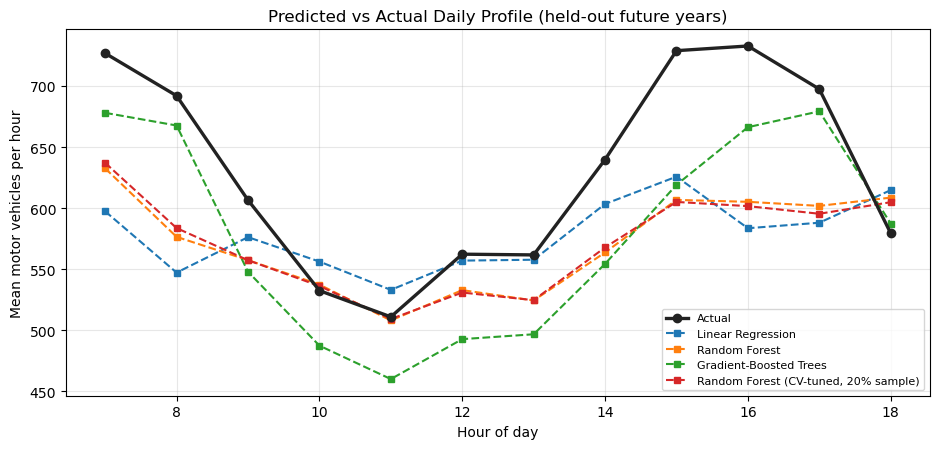

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9.5, 4.6))
drawn = False
for i, r in enumerate(primary["results"]):
    slug = "".join(c if c.isalnum() else "_" for c in r["model"].lower()).strip("_")
    path = resolve("outputs") / "predictions" / f"primary__{slug}.parquet"
    if not path.exists():
        continue
    g = pd.read_parquet(path).groupby("hour").agg(actual=("actual","mean"),
                                                  predicted=("prediction","mean"))
    if not drawn:
        ax.plot(g.index, g["actual"], marker="o", color="#222", lw=2.4, label="Actual", zorder=5)
        drawn = True
    ax.plot(g.index, g["predicted"], marker="s", ms=4, ls="--", label=r["model"])

ax.set_xlabel("Hour of day"); ax.set_ylabel("Mean motor vehicles per hour")
ax.set_title("Predicted vs Actual Daily Profile (held-out future years)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Only **Gradient-Boosted Trees** tracks the curve. The linear model is nearly flat — which
is the visual form of its 0.14% skill. Every model sits below the actual at every hour.

## 9. The warehouse — parameterised queries

What a planner would actually ask.

In [9]:
from src.db.queries import connect, peak_hour_by_road_class, peakiest_links

conn = connect()
try:
    pivot = (peak_hour_by_road_class(conn)
             .pivot(index="hour", columns="road_category", values="mean_peak_index"))
    print("Peak index by road class (1.0 = that class's average hour):\n")
    print(pivot.to_string())
finally:
    conn.close()

Peak index by road class (1.0 = that class's average hour):

road_category      MB     MCU      PA      PM      TA      TM
hour                                                         
7              0.9384  0.8160  0.9696  1.1590  1.0287  1.1569
8              1.2439  1.3289  1.1749  1.2201  1.1445  1.1406
9              0.9105  0.9109  0.9317  0.9599  0.9235  0.9271
10             0.8279  0.8068  0.8521  0.8203  0.8716  0.8440
11             0.8534  0.8449  0.8734  0.8259  0.8813  0.8521
12             0.8777  0.8836  0.9052  0.8606  0.8938  0.8680
13             0.8888  0.8811  0.9244  0.8995  0.9195  0.9004
14             0.9422  0.9338  0.9584  0.9401  0.9640  0.9482
15             1.0967  1.1874  1.0532  1.0217  1.0512  1.0312
16             1.2151  1.1959  1.1750  1.1775  1.1976  1.1835
17             1.2760  1.2532  1.2251  1.1826  1.2183  1.1979
18             0.9294  0.9575  0.9570  0.9327  0.9062  0.9502


**Motorways (TM/PM) peak at 07:00 and flat. Minor roads (MCU) peak at 08:00 and much
sharper, with a second bump at 15:00** — the school run. Long-distance traffic starts
earlier; local traffic peaks with the school-and-work run. Raw flow cannot show this: the
level gap between a motorway and a lane hides it completely.

In [10]:
conn = connect()
try:
    print("Britain's sharpest-peaking links:\n")
    print(peakiest_links(conn, limit=10, min_observations=10).to_string(index=False))
finally:
    conn.close()

Britain's sharpest-peaking links:

road_name road_category local_authority_name  peak_hour  peak_index  peak_hour_flow  observations
        U           MCU              Norfolk          8       4.227           101.5            18
        U           MCU          West Sussex          8       3.780            69.9            14
        U           MCU    Brighton and Hove         17       3.749            91.3            20
        U           MCU              Walsall          8       3.703            94.4            20
        U           MCU                 Kent          8       3.638            23.0            14
        U           MCU               Dorset          8       3.495            63.6            20
        C           MCU                Devon          8       3.462            66.8            14
        U           MCU Rhondda, Cynon, Taff          8       3.438            91.6            16
        U           MCU           Hillingdon          8       3.416           426.4

Every one is a **minor road**, carrying up to **4.2x its own daily average** in a single
hour. Raw flow would never surface these — they are small roads. Only the normalised peak
index finds them, and they are exactly the "where is capacity strained" list a planner asks
for.

## 10. Injection resistance

The security claim, demonstrated rather than asserted.

In [11]:
from src.db.queries import link_profile

conn = connect()
try:
    for payload_str in ["' OR '1'='1",
                        "CP1'; DROP TABLE fact_hourly_profile; --",
                        "' UNION SELECT name, sql, 1, 1, 1, 1 FROM sqlite_master --"]:
        rows = len(link_profile(conn, payload_str))
        print(f"  rows returned: {rows}   payload: {payload_str[:44]}")
    alive = conn.execute("SELECT COUNT(*) FROM fact_hourly_profile").fetchone()[0]
    print(f"\n  fact_hourly_profile still holds {alive:,} rows - nothing was dropped.")
    print("  Bound as ? parameters, the payloads are values, never parseable SQL.")
finally:
    conn.close()

  rows returned: 0   payload: ' OR '1'='1
  rows returned: 0   payload: CP1'; DROP TABLE fact_hourly_profile; --
  rows returned: 0   payload: ' UNION SELECT name, sql, 1, 1, 1, 1 FROM sq

  fact_hourly_profile still holds 520,812 rows - nothing was dropped.
  Bound as ? parameters, the payloads are values, never parseable SQL.


---

## Conclusion

| | |
|---|---|
| Scale | 5,269,609 real rows, 26 years, 53x the requirement, no synthetic data |
| Best model | Gradient-Boosted Trees, R² 0.861 |
| Trivial baseline | R² 0.857 — *assume each road behaves as it always has* |
| Actual skill | **+0.0045 R²**, ~3% of what the baseline leaves unexplained |
| Models below the baseline | **2 of 4** (Random Forest, and its CV-tuned variant) |
| `hour` importance | **0.009** — in a peak-hour project |

The honest reading: **the shape of the day is partly learnable; the individual count at a
specific link on a specific date is not.** That is what leakage-free evaluation produces. A
model reporting 0.99 here would be evidence of a mistake, not of skill.